# Customer Segmentation Analysis
### Global Electronics Retailer — 11,887 Purchasing Customers

**Author:** _Your Name_
**Dataset:** [Global Electronics Retailer](https://mavenanalytics.io/data-playground/global-electronics-retailer) (Maven Analytics)

Module 4 of 4 (Sales Performance · Geographic Performance · Product Performance · **Customer Segmentation**). This module tests whether demographics (age, gender) actually explain customer value, and builds a simple behavioral (RFM-style) segmentation as the more useful alternative.


## 1. Research Questions

1. Do age and gender meaningfully predict how much a customer is worth?
2. How loyal is the customer base — how many customers buy more than once?
3. How concentrated is revenue — do a small number of customers drive a disproportionate share?
4. What behavioral segments (not demographic ones) are most useful for targeting?


## 2. Methodology

We build an RFM (Recency, Frequency, Monetary) table at the customer level from the shared fact table: **Recency** = days since last order (relative to the dataset's last date), **Frequency** = distinct orders placed, **Monetary** = lifetime revenue. Age is computed from `Birthday` as of the dataset's end date (Feb 20, 2021) and bucketed into standard segments matching the original dashboard (18-25, 26-35, 36-45, 46-60, 60+).

**Framing note:** because this is a durable-electronics retailer, a low repeat-purchase rate is *expected* (people don't buy desktops or TVs often) — we treat one-time buyers as a normal segment to understand, not automatically a retention failure.


In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import matplotlib.pyplot as plt
from data_prep import build_sales_fact_table
from viz_style import apply_style, COLORS, PALETTE, add_titles, add_source_note, money_formatter, pct_formatter

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = build_sales_fact_table()
df["Age"] = (pd.Timestamp("2021-02-20") - df["Birthday"]).dt.days / 365.25
bins = [0, 25, 35, 45, 60, 120]
labels = ["18-25", "26-35", "36-45", "46-60", "60+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)
print(f"{df['CustomerKey'].nunique():,} purchasing customers")

11,887 purchasing customers


## 3. Findings

### 3.1 Demographics Don't Predict Value

60+ is the largest group by headcount, but **revenue per customer is nearly flat across every age group** (~$4,600-4,800) — age doesn't tell you how valuable a customer will be, only how many exist in that bracket.

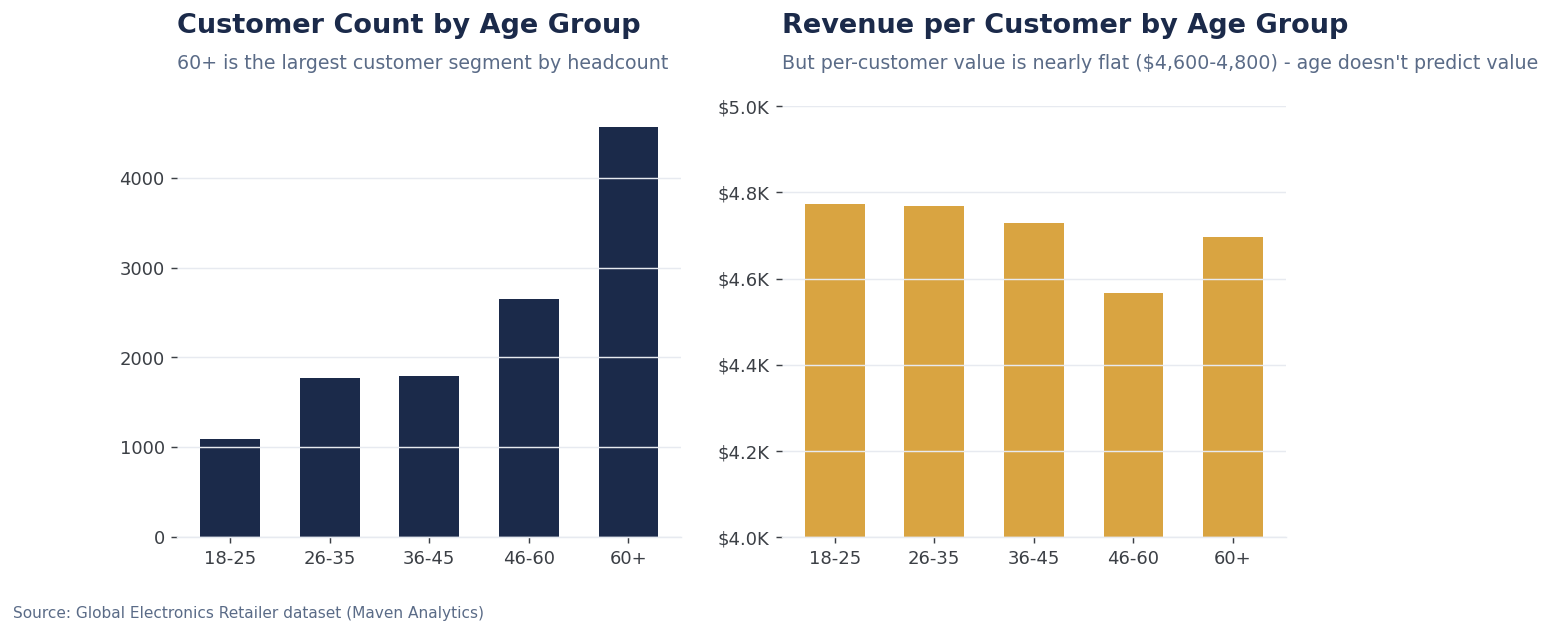

In [2]:
agg = df.groupby("AgeGroup").agg(Revenue=("Revenue_USD","sum"), Customers=("CustomerKey","nunique"))
agg["Rev_per_customer"] = agg["Revenue"] / agg["Customers"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(agg.index.astype(str), agg["Customers"], color=COLORS["primary"], width=0.6)
add_titles(axes[0], "Customer Count by Age Group", "60+ is the largest customer segment by headcount")
axes[1].bar(agg.index.astype(str), agg["Rev_per_customer"], color=COLORS["accent"], width=0.6)
axes[1].yaxis.set_major_formatter(money_formatter())
axes[1].set_ylim(4000, 5000)
add_titles(axes[1], "Revenue per Customer by Age Group", "But per-customer value is nearly flat ($4,600-4,800) - age doesn't predict value")
add_source_note(fig)
plt.savefig("../reports/figures/c01_age_group_analysis.png")
plt.show()

### 3.2 Gender Is Not a Value Signal Either

Male and female customers are worth virtually the same (<1% difference). Any segmentation strategy built around gender would be targeting a variable that carries no real signal in this data.

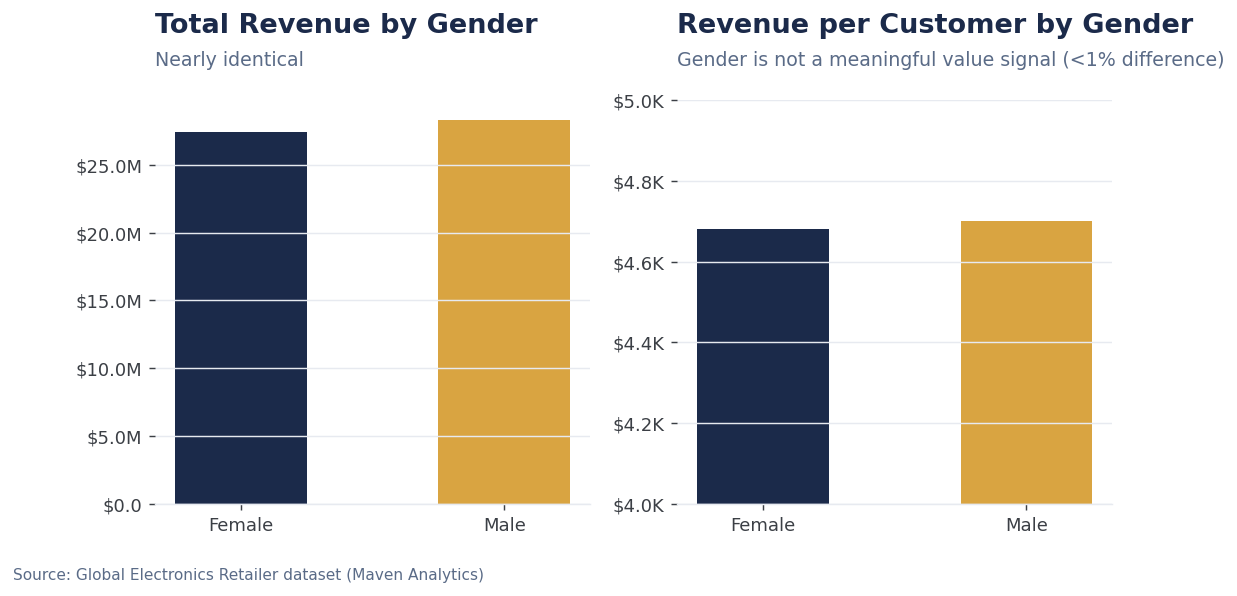

In [3]:
gender = df.groupby("Gender").agg(Revenue=("Revenue_USD","sum"), Customers=("CustomerKey","nunique"))
gender["Rev_per_customer"] = gender["Revenue"] / gender["Customers"]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
axes[0].bar(gender.index, gender["Revenue"], color=[COLORS["primary"], COLORS["accent"]], width=0.5)
axes[0].yaxis.set_major_formatter(money_formatter())
add_titles(axes[0], "Total Revenue by Gender", "Nearly identical")
axes[1].bar(gender.index, gender["Rev_per_customer"], color=[COLORS["primary"], COLORS["accent"]], width=0.5)
axes[1].yaxis.set_major_formatter(money_formatter())
axes[1].set_ylim(4000, 5000)
add_titles(axes[1], "Revenue per Customer by Gender", "Gender is not a meaningful value signal (<1% difference)")
add_source_note(fig)
plt.savefig("../reports/figures/c02_gender_comparison.png")
plt.show()

### 3.3 Purchase Frequency

39% of customers have purchased exactly once — expected for durable electronics, but it's still the single largest segment, so it deserves explicit attention in any lifecycle strategy rather than being an afterthought.

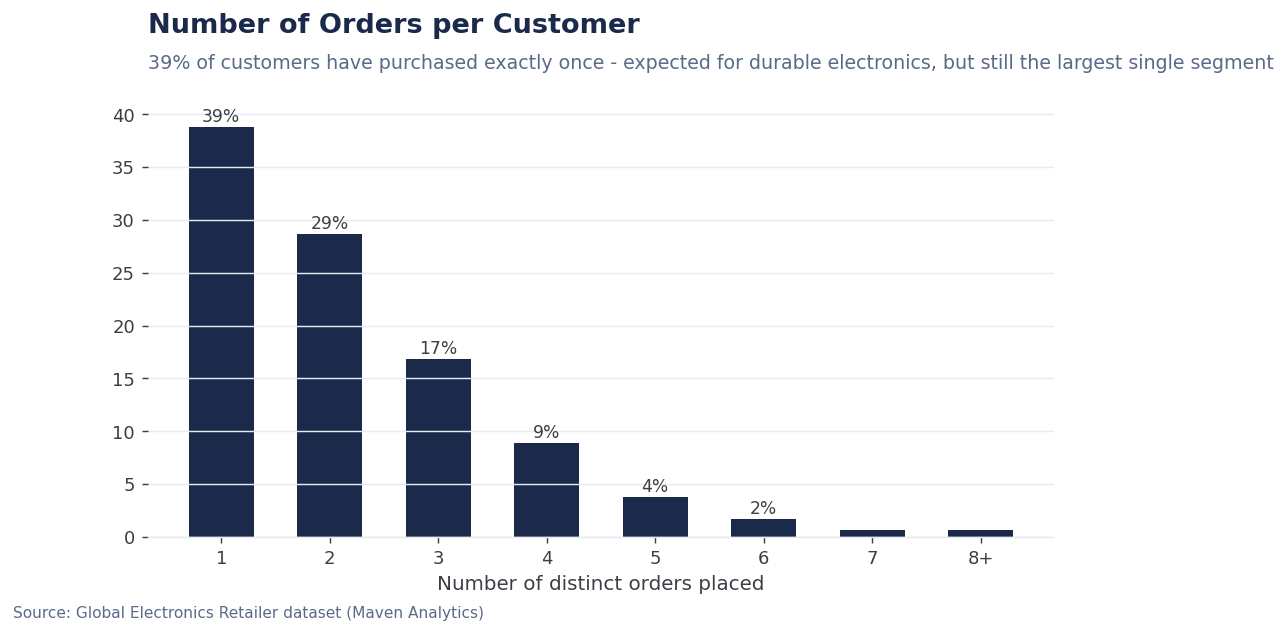

In [4]:
snapshot = df["Order Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerKey").agg(
    Recency=("Order Date", lambda x: (snapshot - x.max()).days),
    Frequency=("Order Number", "nunique"),
    Monetary=("Revenue_USD", "sum"),
)

freq_dist = rfm["Frequency"].clip(upper=8).value_counts(normalize=True).sort_index() * 100
fig, ax = plt.subplots(figsize=(9, 4.8))
labels_f = [str(i) for i in freq_dist.index[:-1]] + ["8+"]
ax.bar(labels_f, freq_dist.values, color=COLORS["primary"], width=0.6)
for i, v in enumerate(freq_dist.values):
    if v > 1:
        ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9.5, color=COLORS["text"])
add_titles(ax, "Number of Orders per Customer", "39% of customers have purchased exactly once - expected for durable electronics, but still the largest single segment")
ax.set_xlabel("Number of distinct orders placed")
add_source_note(fig)
plt.savefig("../reports/figures/c03_order_frequency.png")
plt.show()

### 3.4 Revenue Is Concentrated in a Minority of Customers

The top 10% of customers by spend generate 36% of all revenue — well above the ~10% a perfectly equal distribution would produce. This is the clearest, most actionable segmentation signal in the dataset: **spend history, not demographics, is what should drive VIP treatment.**

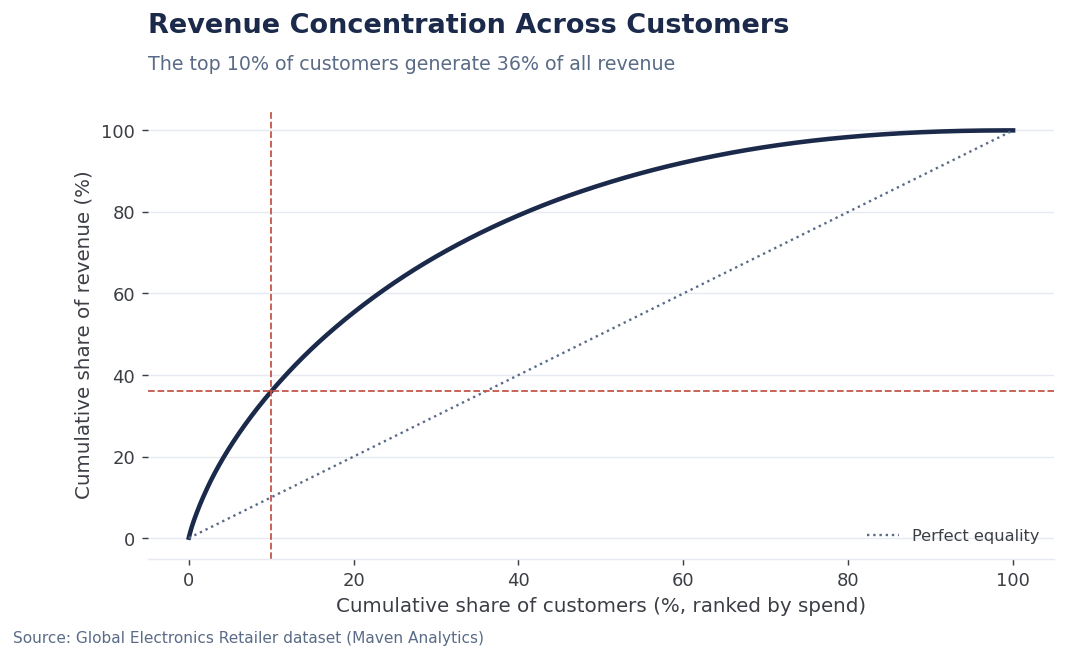

In [5]:
rfm_sorted = rfm.sort_values("Monetary", ascending=False).reset_index(drop=True)
rfm_sorted["cum_revenue_share"] = rfm_sorted["Monetary"].cumsum() / rfm_sorted["Monetary"].sum()
rfm_sorted["cum_customer_share"] = (rfm_sorted.index + 1) / len(rfm_sorted)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rfm_sorted["cum_customer_share"]*100, rfm_sorted["cum_revenue_share"]*100, color=COLORS["primary"], linewidth=2.5)
ax.plot([0,100],[0,100], color=COLORS["muted"], linestyle=":", linewidth=1.3, label="Perfect equality")
ax.axvline(10, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.axhline(36, color=COLORS["negative"], linestyle="--", linewidth=1)
add_titles(ax, "Revenue Concentration Across Customers", "The top 10% of customers generate 36% of all revenue")
ax.set_xlabel("Cumulative share of customers (%, ranked by spend)")
ax.set_ylabel("Cumulative share of revenue (%)")
ax.legend(loc="lower right", fontsize=9)
add_source_note(fig)
plt.savefig("../reports/figures/c04_revenue_concentration.png")
plt.show()

### 3.5 A Practical Behavioral Segmentation

Splitting customers by order count alone produces a far more useful segmentation than demographics: **the "Loyal" segment (4+ orders) is only 16% of customers but drives 34% of revenue** — nearly a 1-to-2.5 disproportion. "Occasional" buyers (2-3 orders) are the volume backbone, at 46% of customers and 49% of revenue.

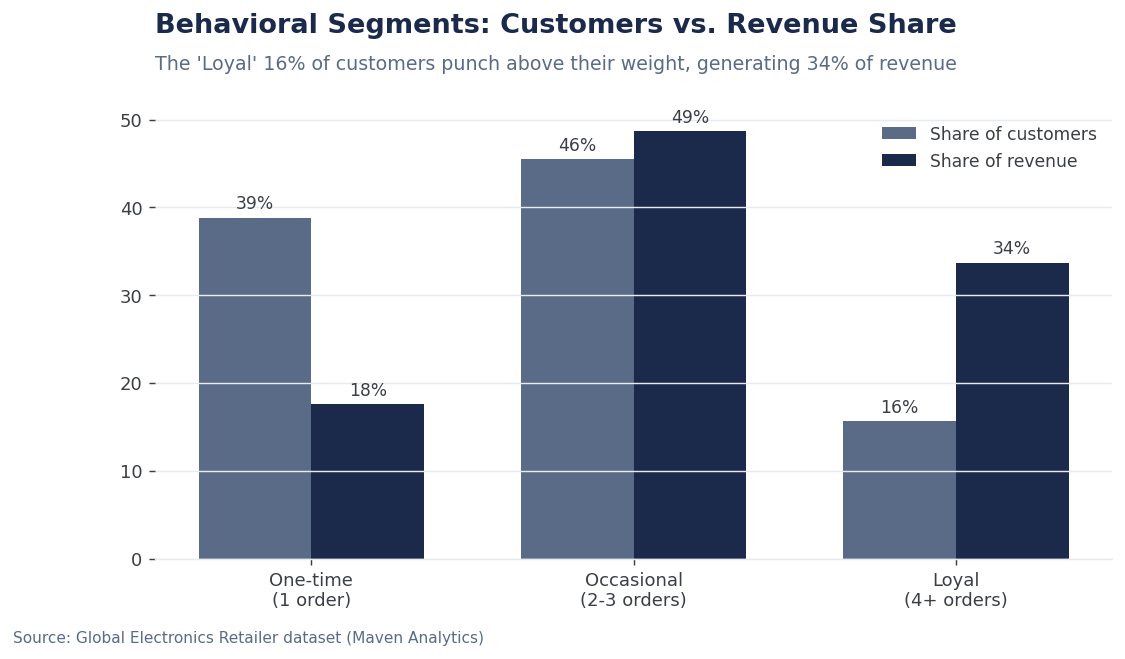

In [6]:
def seg(f):
    if f == 1: return "One-time\n(1 order)"
    elif f <= 3: return "Occasional\n(2-3 orders)"
    else: return "Loyal\n(4+ orders)"
rfm["Segment"] = rfm["Frequency"].apply(seg)
seg_summary = rfm.groupby("Segment").agg(Customers=("Monetary","count"), Revenue=("Monetary","sum"))
seg_summary = seg_summary.reindex(["One-time\n(1 order)","Occasional\n(2-3 orders)","Loyal\n(4+ orders)"])
seg_summary["Cust_share"] = seg_summary["Customers"]/seg_summary["Customers"].sum()*100
seg_summary["Rev_share"] = seg_summary["Revenue"]/seg_summary["Revenue"].sum()*100

fig, ax = plt.subplots(figsize=(9.5, 5))
x = range(len(seg_summary)); w = 0.35
ax.bar([i-w/2 for i in x], seg_summary["Cust_share"], width=w, color=COLORS["muted"], label="Share of customers")
ax.bar([i+w/2 for i in x], seg_summary["Rev_share"], width=w, color=COLORS["primary"], label="Share of revenue")
ax.set_xticks(list(x)); ax.set_xticklabels(seg_summary.index)
for i,(c,r) in enumerate(zip(seg_summary["Cust_share"], seg_summary["Rev_share"])):
    ax.text(i-w/2, c+1, f"{c:.0f}%", ha="center", fontsize=9.5)
    ax.text(i+w/2, r+1, f"{r:.0f}%", ha="center", fontsize=9.5)
add_titles(ax, "Behavioral Segments: Customers vs. Revenue Share", "The 'Loyal' 16% of customers punch above their weight, generating 34% of revenue")
ax.legend(loc="upper right", fontsize=9.5)
add_source_note(fig)
plt.savefig("../reports/figures/c05_behavioral_segments.png")
plt.show()

### 3.6 Recency Context

Most of the base hasn't ordered recently, but this mostly reflects the dataset spanning more than five years for an infrequently-purchased category, rather than active churn — a proper lifecycle/win-back program would need a shorter, rolling recency window than the one available here.

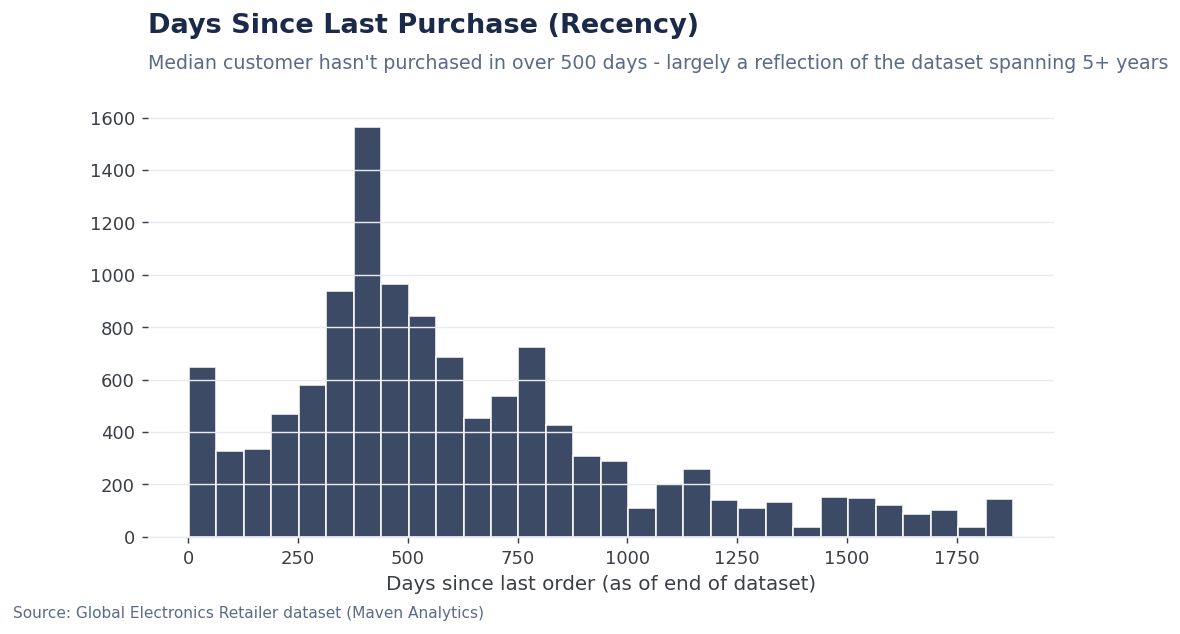

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(rfm["Recency"], bins=30, color=COLORS["primary"], alpha=0.85, edgecolor="white")
add_titles(ax, "Days Since Last Purchase (Recency)", "Median customer hasn't purchased in over 500 days - largely a reflection of the dataset spanning 5+ years")
ax.set_xlabel("Days since last order (as of end of dataset)")
add_source_note(fig)
plt.savefig("../reports/figures/c06_recency_distribution.png")
plt.show()

## 4. Business Conclusions & Recommendations

1. **Retire demographic targeting (age/gender) for value-based decisions.** Neither predicts customer worth in this data — budget currently spent segmenting campaigns by age bracket or gender would be better spent on behavioral segments.

2. **Build a real VIP program around the top 10%.** They already generate over a third of revenue without any formal recognition program — even a lightweight loyalty tier (early access, extended warranty, free shipping) could improve retention of the highest-value 10%.

3. **Treat "Occasional" (2-3 order) customers as the core growth lever.** They're already the single largest revenue contributor (49%) — a well-timed second/third-purchase nudge (e.g., accessory bundle, extended-warranty upsell) has the largest addressable base to work with.

4. **Don't over-invest in "winning back" one-time buyers as if it were unusual churn.** For durable electronics, a single purchase over 5 years is a normal pattern; resources are better spent converting them to a second purchase (bundling, financing options) than on aggressive reactivation campaigns.

5. **Recency-based campaigns need a shorter, rolling window than this static dataset provides** — in production, recompute Recency against "today," not a fixed historical cutoff, before acting on it.
